In [1]:
import logging

import fastf1 as ff1
import fastf1.plotting
from matplotlib import pyplot as plt

ff1.logger.set_log_level(logging.ERROR)
%matplotlib widget

In [2]:
session = ff1.get_session(2025, 23, "R")
session.load()
laps = session.laps

In [3]:
drivers = session.drivers
drivers

['1',
 '81',
 '55',
 '4',
 '12',
 '63',
 '14',
 '16',
 '30',
 '22',
 '23',
 '44',
 '5',
 '43',
 '31',
 '10',
 '18',
 '6',
 '87',
 '27']

In [4]:
drivers = [session.get_driver(driver)["Abbreviation"] for driver in drivers]
drivers

['VER',
 'PIA',
 'SAI',
 'NOR',
 'ANT',
 'RUS',
 'ALO',
 'LEC',
 'LAW',
 'TSU',
 'ALB',
 'HAM',
 'BOR',
 'COL',
 'OCO',
 'GAS',
 'STR',
 'HAD',
 'BEA',
 'HUL']

In [5]:
stints = laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"])
stints = stints.count().reset_index()

In [6]:
stints = stints.rename(columns={"LapNumber": "StintLength"})
stints

,Driver,Stint,Compound,StintLength
0,ALB,1.0,HARD,7
1,ALB,2.0,MEDIUM,25
2,ALB,3.0,MEDIUM,25
3,ALO,1.0,MEDIUM,7
4,ALO,2.0,MEDIUM,25
...,...,...,...,...
56,TSU,2.0,MEDIUM,25
57,TSU,3.0,HARD,25
58,VER,1.0,MEDIUM,7
59,VER,2.0,MEDIUM,25


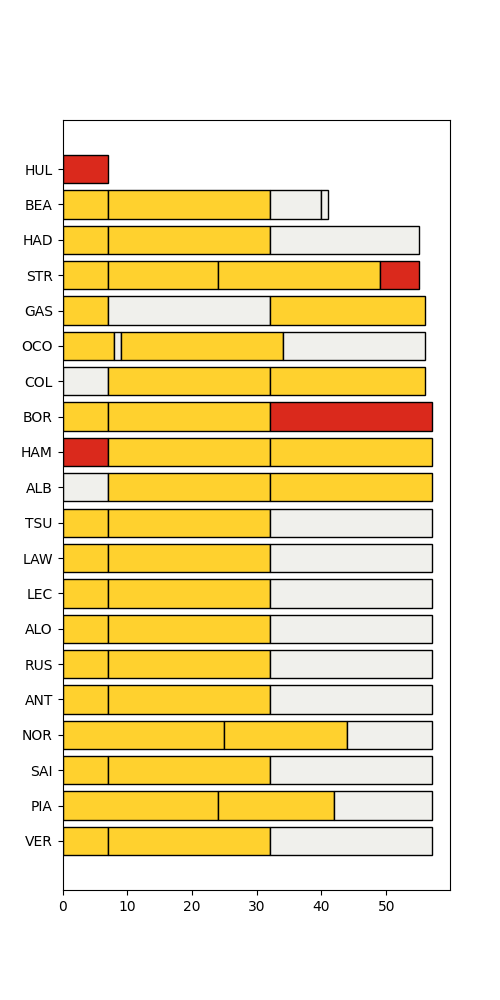

In [7]:
fig, ax = plt.subplots(figsize=(5, 10))

for driver in drivers:
    driver_stints = stints.loc[stints["Driver"] == driver]

    previous_stint_end = 0
    for idx, row in driver_stints.iterrows():
        compound_color = ff1.plotting.get_compound_color(row["Compound"],
                                                         session=session)
        plt.barh(
            y=driver,
            width=row["StintLength"],
            left=previous_stint_end,
            color=compound_color,
            edgecolor="black",
            fill=True,
        )

        previous_stint_end += row["StintLength"]

In [8]:
plt.title("2025 Qatar Grand Prix")
plt.xlabel("Lap Number")
plt.grid(False)
ax.invert_yaxis()

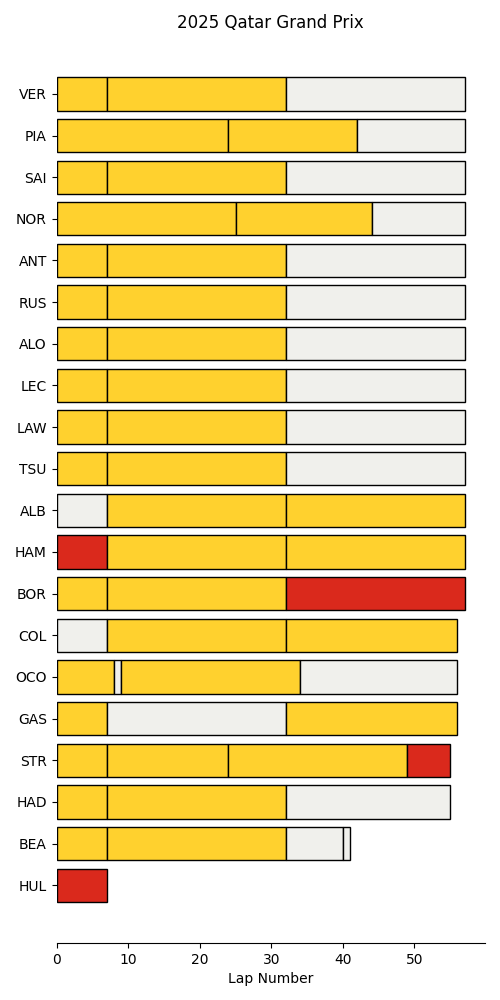

In [9]:
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()